# Temperature analysis notebook

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import numpy as np
from scipy.stats import ttest_ind
import xarray as xr
import pandas as pd
import cartopy.crs as ccrs
import cartopy
from cartopy.util import add_cyclic_point
plt.rcParams['figure.figsize'] = (12, 5)
from IPython.display import display, Markdown

import sys
sys.path.append("/gpfs/data/fs72044/avoigt_teach/msc-climodlab-s2026/msc-climate-modeling-lab-s2026-code4students/analysis/")
import core as core

/home/fs72044/icon18/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
path_2d_1co2_187_5 = '/gpfs/data/fs72044/icon15/simulations/slab187_1co2/slab187_1co2_atm_2d_2000_2025_remap_sic.nc'

path_2d_2co2_187_5 = '/gpfs/data/fs72044/icon15/simulations/slab187_2co2/slab187_2co2_atm_2d_2000_2035_remap_sic.nc'

path_2d_1co2_375 = '/gpfs/data/fs72044/icon18/experiments/s2026/slabcn2sea375/slab375_1co2_2d_2000_2035.cell_area.r360x180.nc'

path_sic_1co2_375 = '/gpfs/data/fs72044/icon18/experiments/s2026/slabcn2sea375/slab375_1co2_2d_seaice.nc'

path_2d_2co2_375 = '/gpfs/data/fs72044/icon15/simulations/slab375_2co2/slab375_2co2_atm_2d_2000_2035_remap_sic.nc'

path_2d_1co2_560 = '/gpfs/data/fs72044/icon28/Simulations/slabcn560/slabcn560_1co2_2d_2000-2035_remapped.nc'

path_2d_2co2_560 = '/gpfs/data/fs72044/icon28/Simulations/slabcn560doubledco2/slabcn560doubledco2_2d_2000_2019_remapped.nc'

path_sic_1co2_560 = '/gpfs/data/fs72044/icon28/Simulations/slabcn560/slab560_1_sic.nc'

path_sic_2co2_560 = '/gpfs/data/fs72044/icon28/Simulations/slabcn560doubledco2/slab560_2_sic.nc'

path_ctrl_2d = '/gpfs/data/fs72044/avoigt_teach/experiments/s2026/slabctr/slabctr_atm_2d_ml_1979-2035.remapcon-r360x180.nc'

In [3]:
ds2d_1co2_187_5 = core.correct_timeaxis(xr.open_dataset(path_2d_1co2_187_5)).sortby('time').sel(time=slice('2000-01-01', '2024-12-31')) # infinite values at the end

ds2d_2co2_187_5 = core.correct_timeaxis(xr.open_dataset(path_2d_2co2_187_5))

ds2d_1co2_375 = core.correct_timeaxis(xr.open_dataset(path_2d_1co2_375)).sortby('time')

ds2d_2co2_375 = core.correct_timeaxis(xr.open_dataset(path_2d_2co2_375))

ds2d_1co2_560 = core.correct_timeaxis(xr.open_dataset(path_2d_1co2_560))

ds2d_2co2_560 = core.correct_timeaxis(xr.open_dataset(path_2d_2co2_560))

ctrl_2d = core.correct_timeaxis(xr.open_dataset(path_ctrl_2d))

ds_sic_1co2_375 = core.correct_timeaxis(xr.open_dataset(path_sic_1co2_375))

ds_sic_1co2_560 = core.correct_timeaxis(xr.open_dataset(path_sic_1co2_560))

ds_sic_2co2_560 = core.correct_timeaxis(xr.open_dataset(path_sic_2co2_560))

## Main plots

In [4]:
datasets= [ds2d_1co2_187_5, ds2d_2co2_187_5, ds2d_1co2_375, ds2d_2co2_375, ds2d_1co2_560, ds2d_2co2_560]
datasets_sic = [ds2d_1co2_187_5, ds2d_2co2_187_5, ds_sic_1co2_375, ds2d_2co2_375, ds_sic_1co2_560, ds_sic_2co2_560]
ds_colors = ['tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green']
ds_linestyles = ['solid', 'dashed', 'solid', 'dashed', 'solid', 'dashed']
ds_labels = ['1*CO$_2$ 187.5 cm$^{-3}$', '2*CO$_2$ 187.5 cm$^{-3}$', '1*CO$_2$ 375 cm$^{-3}$', '2*CO$_2$ 375 cm$^{-3}$', '1*CO$_2$ 560 cm$^{-3}$', '2*CO$_2$ 560 cm$^{-3}$']

In [5]:
label_colors = ['grey', 'grey', 'black', 'tab:blue', 'tab:orange', 'tab:green']
label_linestyles = ['solid', 'dashed', 'solid', 'solid', 'solid', 'solid']

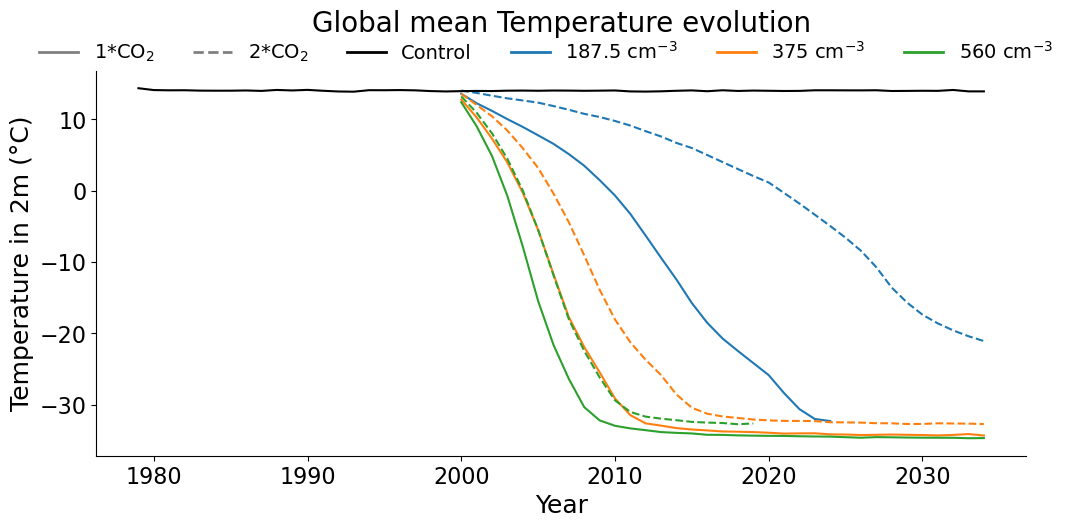

In [6]:
ctrl_glob_mean = core.global_mean(ctrl_2d.tas.sel(time=slice('1979-01-01', '2035-01-01')))
ctrl = ctrl_glob_mean.groupby('time.year').mean(dim='time') -273.15

fig, ax = plt.subplots(1, 1, figsize=(12,5))
for i, ds in enumerate(datasets):
    glob_mean = core.global_mean(ds.tas)
    mcb = glob_mean.groupby('time.year').mean(dim='time') -273.15
    
    ax.plot(mcb.year, mcb, color=ds_colors[i], label=ds_labels[i], linestyle=ds_linestyles[i])
ax.plot(ctrl.year, ctrl, color='black', label='Control')

ax.set_xlabel('Year', fontsize=18)
ax.set_ylabel('Temperature in 2m (°C)', fontsize=18)
ax.tick_params(labelsize=16)
handles = [Line2D([0], [0], color=col, lw=2, linestyle=lnst) for col, lnst in zip(label_colors, label_linestyles)]
labels = ['1*CO$_2$', '2*CO$_2$', 'Control', '187.5 cm$^{-3}$', '375 cm$^{-3}$', '560 cm$^{-3}$']
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.975), ncol=6, fontsize=14, frameon=False)
ax.set_title('Global mean Temperature evolution', fontsize=20, y=1.08)
ax.spines[['right', 'top']].set_visible(False)
plt.show()

#plt.savefig('global_mean_temp_evolution_new.pdf', dpi=300, bbox_inches='tight')

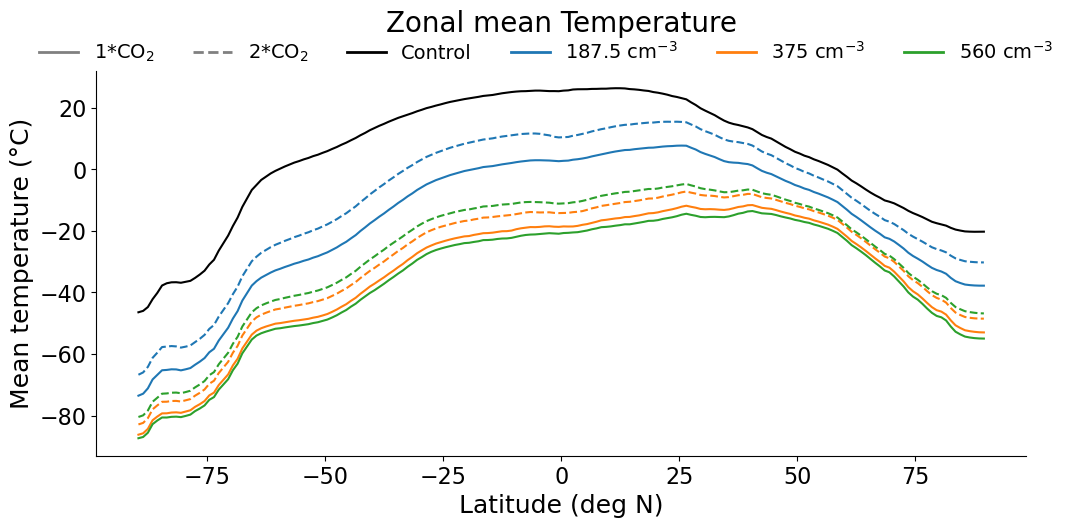

In [7]:
zon_mean_ctrl = ctrl_2d.tas.sel(time=slice('2000-01-01', '2035-01-01')).mean(dim='lon').mean(dim='time') -273.15

fig, ax = plt.subplots(1, 1, figsize=(12,5))

for i, ds in enumerate(datasets):
    zon_mean_mcb = ds.tas.mean(dim='lon').mean(dim='time') -273.15
    ax.plot(zon_mean_mcb.lat, zon_mean_mcb, color=ds_colors[i], label=ds_labels[i], linestyle=ds_linestyles[i])
ax.plot(zon_mean_ctrl.lat, zon_mean_ctrl, color='black', label='Control')

ax.set_xlabel('Latitude (deg N)', fontsize=18)
ax.set_ylabel('Mean temperature (°C)', fontsize=18)
ax.tick_params(labelsize=16)
handles = [Line2D([0], [0], color=col, lw=2, linestyle=lnst) for col, lnst in zip(label_colors, label_linestyles)]
labels = ['1*CO$_2$', '2*CO$_2$', 'Control', '187.5 cm$^{-3}$', '375 cm$^{-3}$', '560 cm$^{-3}$']
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.975), ncol=6, fontsize=14, frameon=False)
ax.set_title('Zonal mean Temperature', fontsize=20, y=1.08)
ax.spines[['right', 'top']].set_visible(False)
plt.show()

#plt.savefig('zonal_mean_temp_new.pdf', dpi=300, bbox_inches='tight')

In [8]:
ctrl_mean_temp = ctrl_glob_mean.mean(dim='time') -273.15
display(Markdown(f'Control global temperature mean (2000-2035): {ctrl_mean_temp.values:.3f} °C'))
for i, ds in enumerate(datasets):
    valid_years = (str(ds.time.dt.year.max().values-10), str(ds.time.dt.year.max().values))
    mcb_mean_temp = core.global_mean(ds.sel(time=slice(*valid_years)).tas).mean(dim='time') -273.15
    label= ds_labels[i]
    display(Markdown(f'{label} global mean temperature ({valid_years[0]} - {valid_years[1]}): {mcb_mean_temp.values:.3f} °C'))

Control global temperature mean (2000-2035): 13.998 °C

1*CO$_2$ 187.5 cm$^{-3}$ global mean temperature (2014 - 2024): -23.869 °C

2*CO$_2$ 187.5 cm$^{-3}$ global mean temperature (2024 - 2034): -14.279 °C

1*CO$_2$ 375 cm$^{-3}$ global mean temperature (2024 - 2034): -34.223 °C

2*CO$_2$ 375 cm$^{-3}$ global mean temperature (2024 - 2034): -32.607 °C

1*CO$_2$ 560 cm$^{-3}$ global mean temperature (2024 - 2034): -34.604 °C

2*CO$_2$ 560 cm$^{-3}$ global mean temperature (2009 - 2019): -31.376 °C

In [9]:
def fix_lon(da):
    # credit to Julian Kragler for this function
    """Add a cyclic point at lon=360° so contourf closes the seam at the dateline."""
    data, lons = add_cyclic_point(da.values, coord=da.lon.values)
    return da.assign_coords(lon=lons).reindex(lon=lons) if False else \
        da.__class__(data, dims=da.dims,
                     coords={**{k: v for k, v in da.coords.items() if k != 'lon'},
                             'lon': lons},
                     attrs=da.attrs)

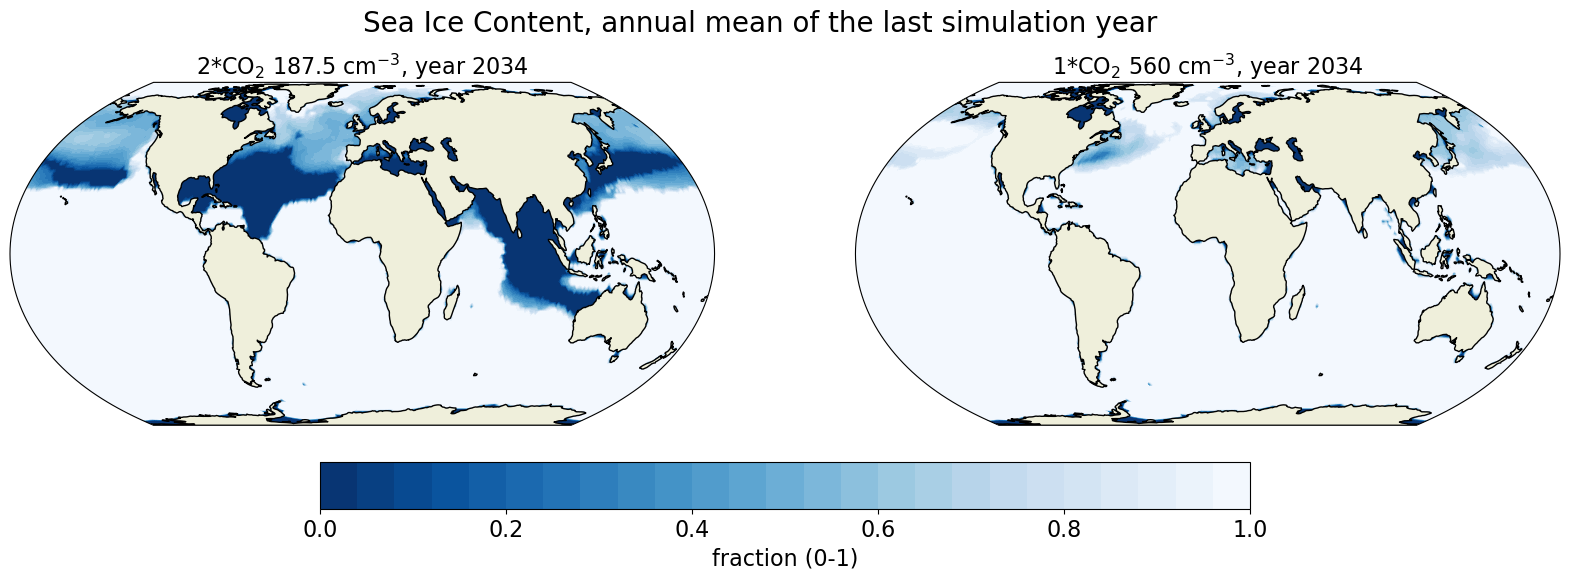

In [10]:
# sea ice

fig = plt.figure(figsize=(20,6))

# warmest run: 2*CO2 at 187.5 cm-3
last_year_mean_187 = fix_lon(ds2d_2co2_187_5.sel(time='2034').sic).mean(dim='time')
ax1 = plt.subplot(1, 2, 1, projection=ccrs.EqualEarth())
im1 = ax1.contourf(last_year_mean_187.lon, last_year_mean_187.lat, last_year_mean_187,
                           transform=ccrs.PlateCarree(), cmap='Blues_r',
                           levels=30, vmin=0, vmax=1)
ax1.add_feature(cartopy.feature.LAND, zorder=100, edgecolor='k')
ax1.set_title('2*CO$_2$ 187.5 cm$^{-3}$, year 2034', fontsize=16)

# coldest run: 1*CO2 at 560 cm-3
last_year_mean_560 = fix_lon(ds_sic_1co2_560.sel(time='2034').sic).mean(dim='time')
ax2 = plt.subplot(1, 2, 2, projection=ccrs.EqualEarth())
im2 = ax2.contourf(last_year_mean_560.lon, last_year_mean_560.lat, last_year_mean_560,
                           transform=ccrs.PlateCarree(), cmap='Blues_r',
                           levels=30, vmin=0, vmax=1)
ax2.add_feature(cartopy.feature.LAND, zorder=100, edgecolor='k')
ax2.set_title('1*CO$_2$ 560 cm$^{-3}$, year 2034', fontsize=16)

cbar = fig.colorbar(im2, ax=[ax1, ax2], orientation='horizontal', ticks=np.linspace(0, 1, 6), pad=0.08, shrink=0.6)
cbar.set_label('fraction (0-1)', size=16)
cbar.ax.tick_params(labelsize=16)

plt.suptitle('Sea Ice Content, annual mean of the last simulation year', fontsize=20, va='top')

plt.show()
#plt.savefig('sic_187_560.pdf', dpi=300, bbox_inches='tight')

## Extra plots

In [11]:
def compute_ttest(ds_exp, ds_ctr, var="tas", years=("2000","2014")):
    # credit to Raúl Muñoz Ruiz for this function
    exp = ds_exp[var].sel(time=slice(*years))
    ctr = ds_ctr[var].sel(time=slice(*years))

    # scipy t-test
    tstat, pval = ttest_ind(
        exp,
        ctr,
        axis=0,
        equal_var=False,
        nan_policy="omit"
    )

    return xr.DataArray(
        pval,
        coords={
            "lat": ds_exp.lat,
            "lon": ds_exp.lon
        },
        dims=["lat","lon"]
    )

In [12]:
def plot_diff_global(ds, ctrl, title=None):
    valid_years = (str(ds.time.dt.year.min().values), str(ds.time.dt.year.max().values))
    mcb_global = ds.tas.mean(dim='time')
    ctrl_global = ctrl.tas.sel(time=slice(*valid_years)).mean(dim='time')
    
    pval = compute_ttest(ds, ctrl, var='tas', years=valid_years)

    sig = pval > 0.05

    anom = mcb_global - ctrl_global
    ax = plt.axes(projection=ccrs.EqualEarth())
    if anom.max() >= 0:
        colormap = 'RdBu_r'
        anom.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=colormap,
                  vmin=anom.min()-1, vmax=anom.max()+1,
                  cbar_kwargs={'label': 'Temperature anomaly (°C)',
                               'pad': 0.1})
    else:
        colormap = 'Blues_r'
        anom.plot(ax=ax, transform=ccrs.PlateCarree(), cmap=colormap,
                  vmin=-63, vmax=1,
                  cbar_kwargs={'label': 'Temperature anomaly (°C)',
                               'pad': 0.02})
    
    # significance hatching
    ax.contourf(
        ds.lon,
        ds.lat,
        sig,
        levels=[0.5,1],
        hatches=["...."],
        colors="none",
        transform=ccrs.PlateCarree()
    )
    
    ax.coastlines()
    
    # Legend for insignificant areas
    hatch_proxy = mpl.patches.Patch(facecolor='none', edgecolor='0.3', hatch='....',
                        label='Not significant at 5%')
    ax.legend(handles=[hatch_proxy], loc=(0.31,-.12), frameon=True, fontsize=16)

    if title != None:
        ax.set_title(title, fontsize=20)
    plt.show()
    #plt.savefig(title.replace(' ', '_')+'.png', dpi=300, bbox_inches='tight')

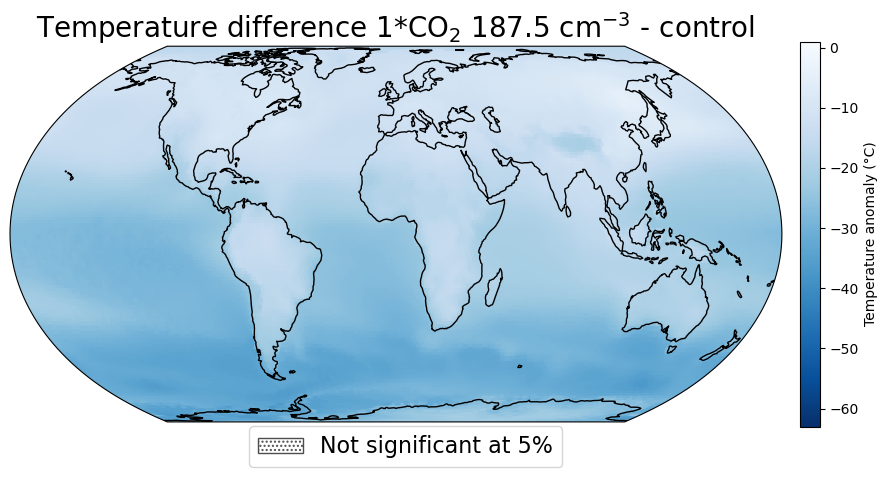

In [13]:
plot_diff_global(ds2d_1co2_187_5, ctrl_2d, 'Temperature difference 1*CO$_2$ 187.5 cm$^{-3}$ - control')

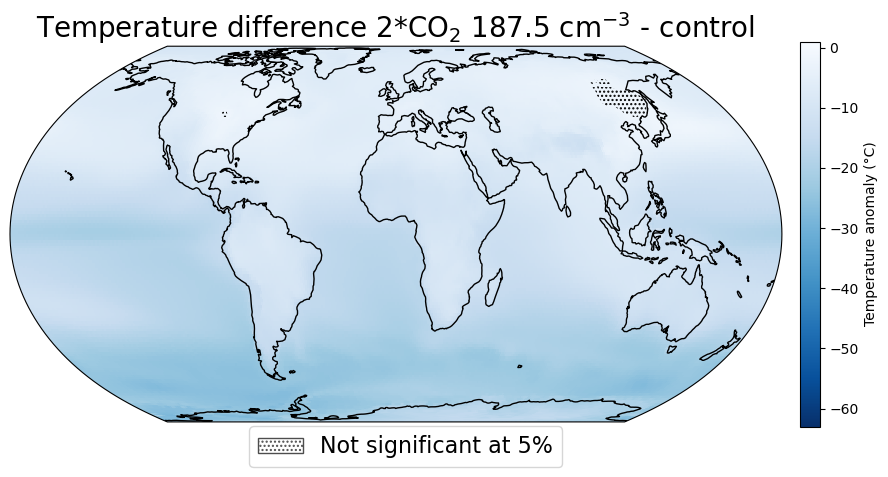

In [14]:
plot_diff_global(ds2d_2co2_187_5, ctrl_2d, 'Temperature difference 2*CO$_2$ 187.5 cm$^{-3}$ - control')

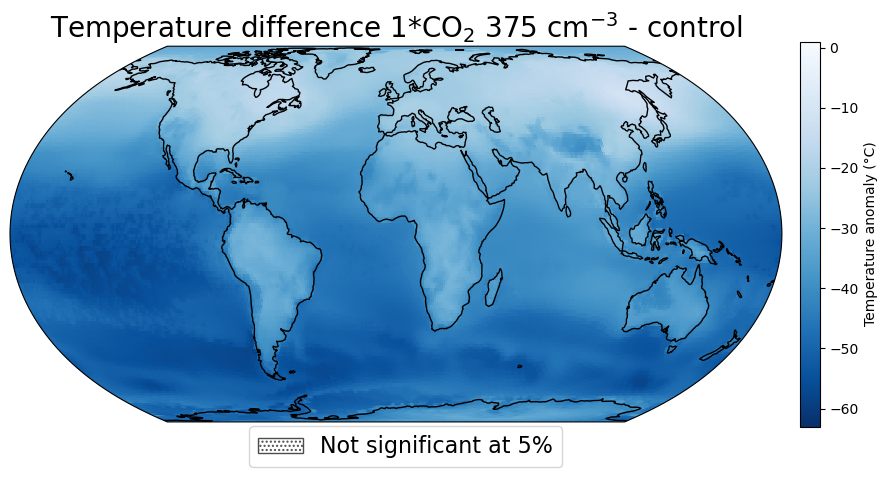

In [16]:
plot_diff_global(ds2d_1co2_375, ctrl_2d, 'Temperature difference 1*CO$_2$ 375 cm$^{-3}$ - control')

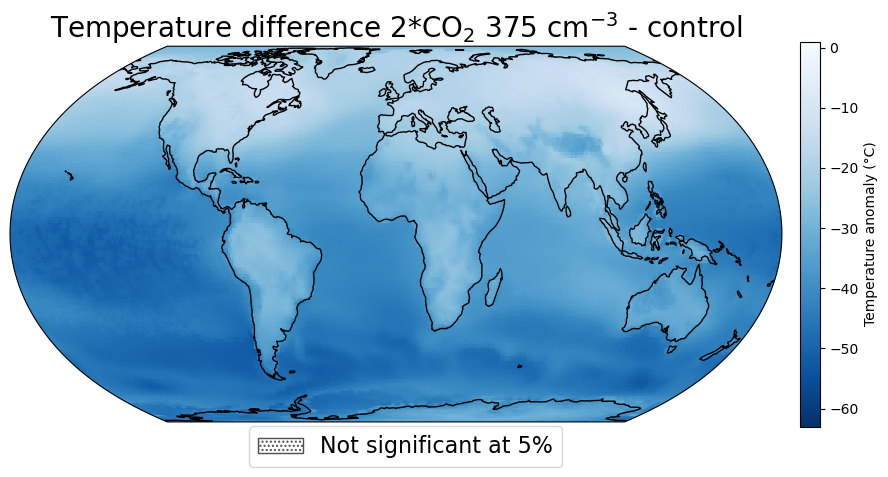

In [17]:
plot_diff_global(ds2d_2co2_375, ctrl_2d, 'Temperature difference 2*CO$_2$ 375 cm$^{-3}$ - control')

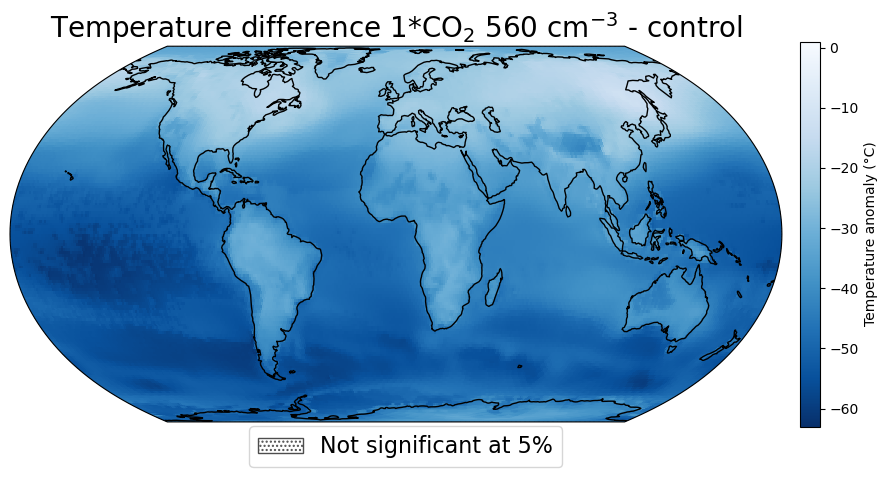

In [18]:
plot_diff_global(ds2d_1co2_560, ctrl_2d, 'Temperature difference 1*CO$_2$ 560 cm$^{-3}$ - control')

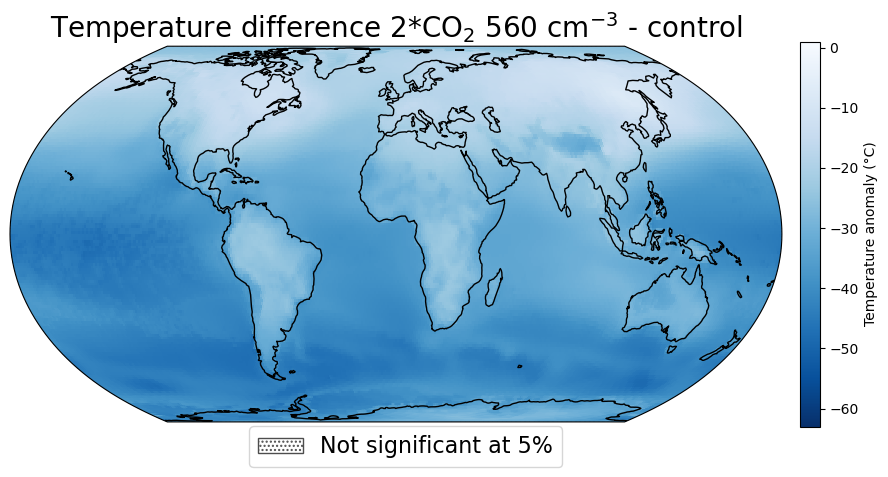

In [19]:
plot_diff_global(ds2d_2co2_560, ctrl_2d, 'Temperature difference 2*CO$_2$ 560 cm$^{-3}$ - control')